In [1]:
import so
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
# Tags
filenames = ['android_c.csv', 'csharp_c.csv', 'java_c.csv', 'other_c.csv', 'python_c.csv', 'r_c.csv', 'web_c.csv']
tags = ['android', 'c#', 'java', 'other', 'python', 'r', 'web']

In [3]:
q_daily = so.load_data('data/csv/final/q_daily.csv', date_column='date')
a_daily = so.load_data('data/csv/final/a_daily.csv', date_column='date')

In [4]:
tag_dfs = {}
for tag, filename in zip(tags, filenames):
    print(f'Loading: {tag}')
    tag_daily = so.load_data(f'data/csv/tags/{filename[:-4]}_daily.csv', date_column='date')
    tag_dfs[tag] = tag_daily

Loading: android
Loading: c#
Loading: java
Loading: other
Loading: python
Loading: r
Loading: web


# Autocorrelation function

In [6]:
def acf(df, type, outcome):
    N = df[f'{outcome}_n'].sum()
    mu = df[f'{outcome}_sum'].sum() / N
    sigma2 = (df[f'{outcome}_ss'].sum() - (df[f'{outcome}_sum'].sum() ** 2) / N) / (N - 1)
    sigma = np.sqrt(sigma2)

    df['ybar_std'] = (df[f'{outcome}_bar'] - mu) / sigma
    res = smf.wls('ybar_std ~ T*P + C(W) + C(D)', data=df, weights=df[f'{outcome}_n']).fit()

    resid = res.resid
    plot_acf(resid, lags=60)
    plt.title(f'{type}: {outcome}')
    plt.show()

## Question/answer daily time series

In [7]:
dfs = {'questions': q_daily, 'answers': a_daily}
outcomes = {'questions': ['line_count', 'log_lc', 'ViewCount', 'Score'],
            'answers': ['line_count', 'log_lc', 'Score']}

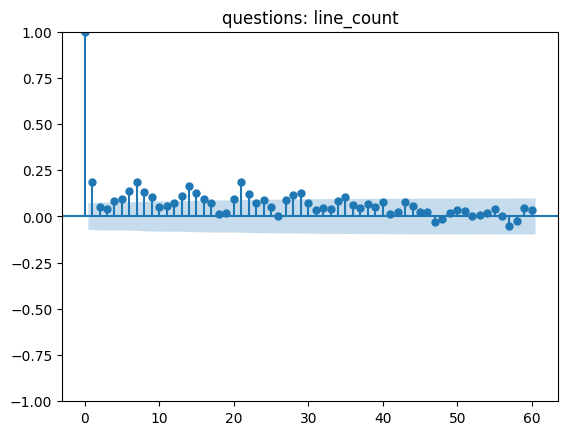

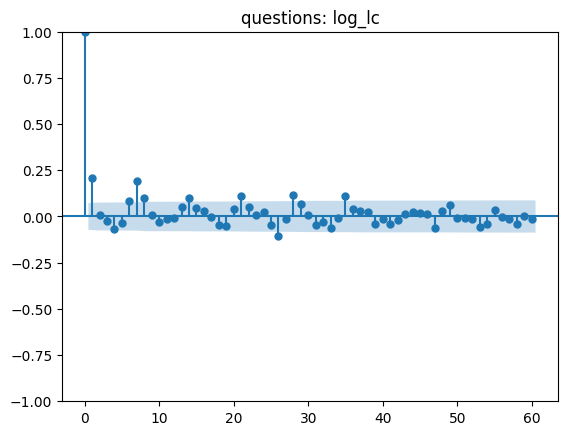

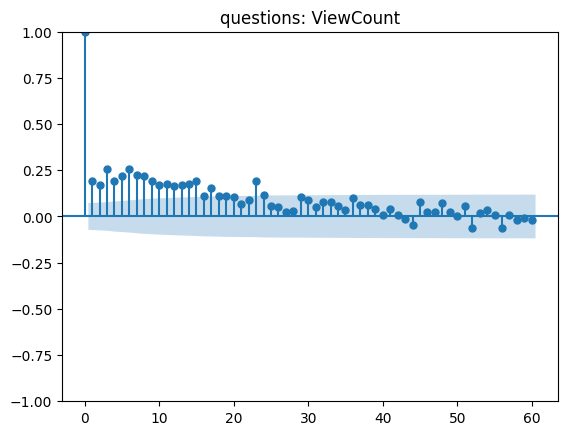

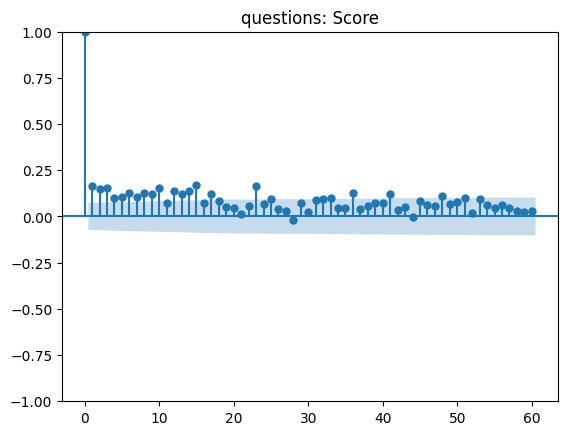

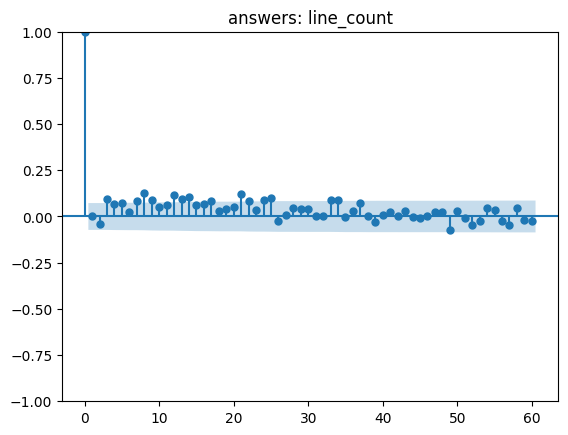

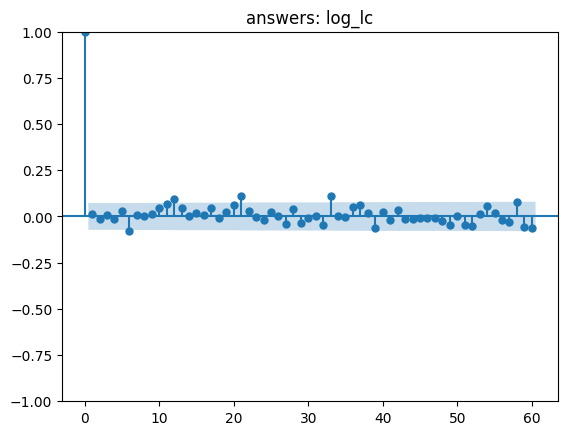

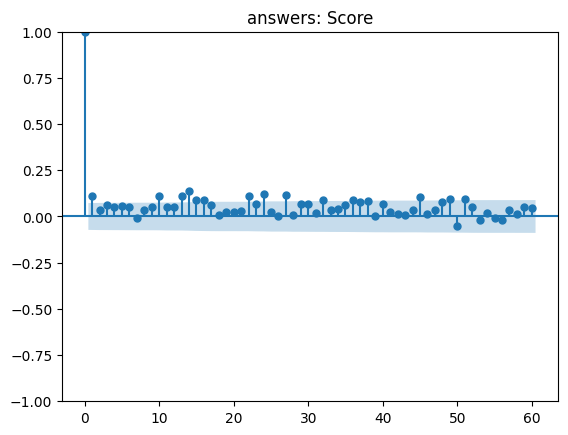

In [8]:
for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            acf(dfs[type], type, outcome) 

### Tag daily time series

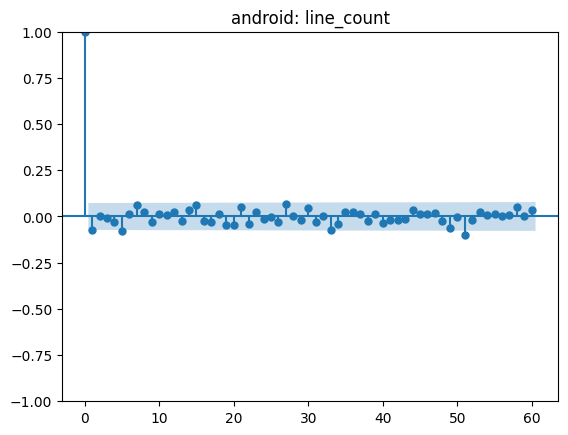

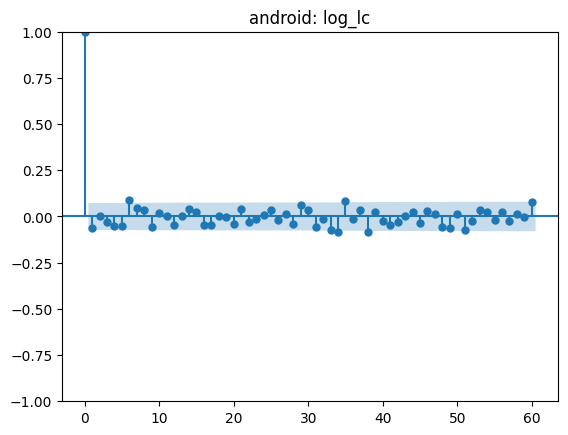

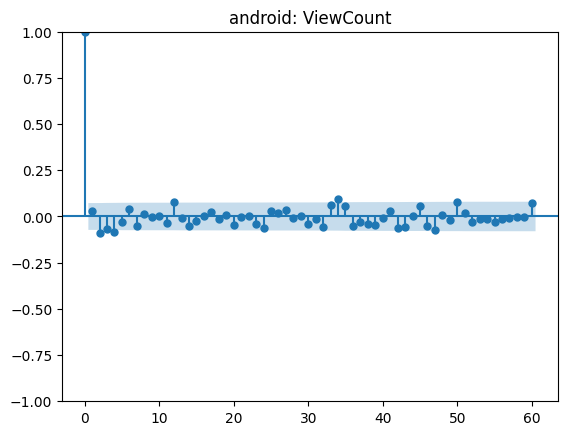

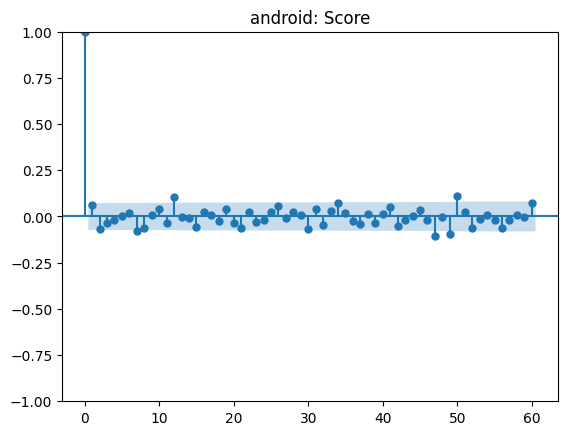

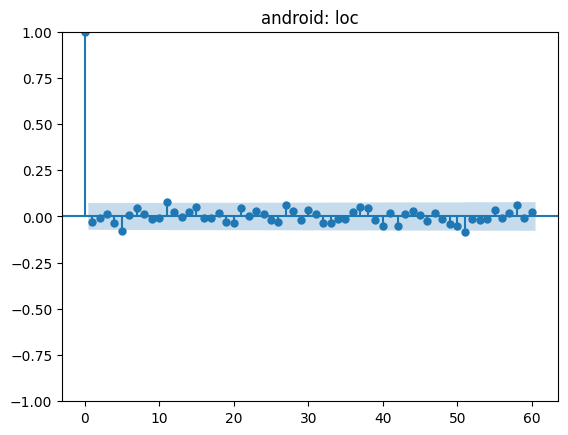

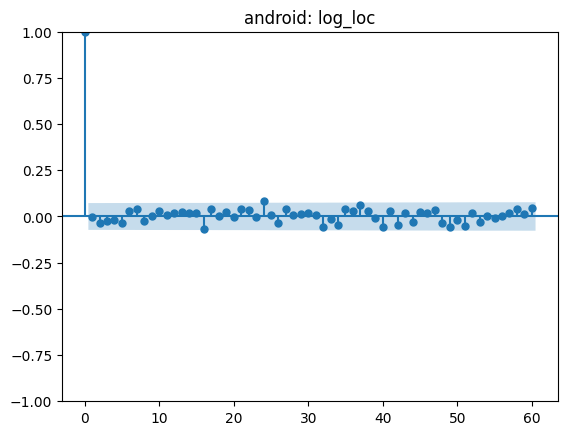

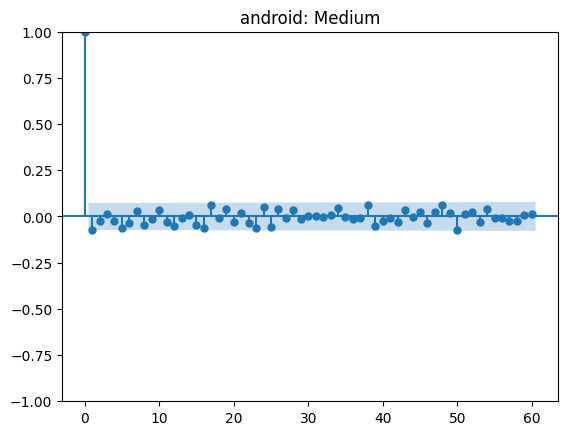

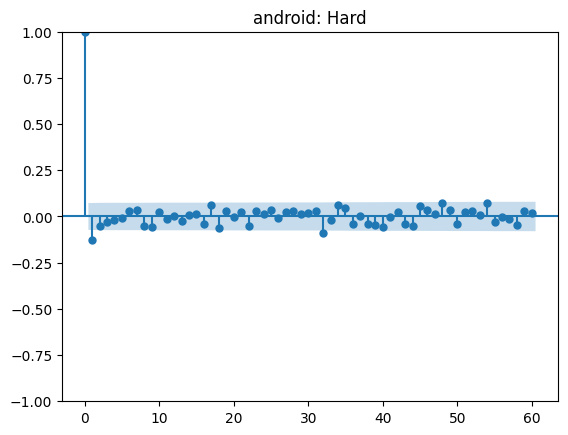

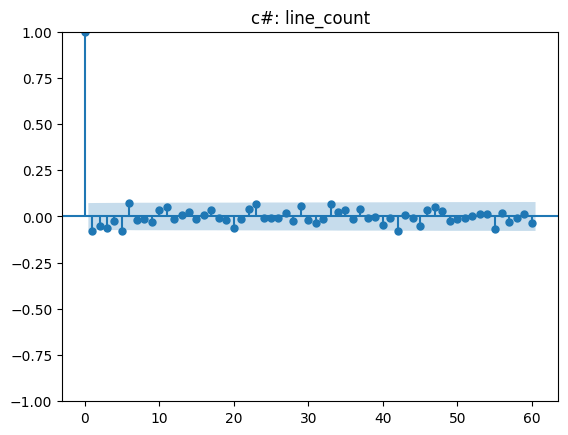

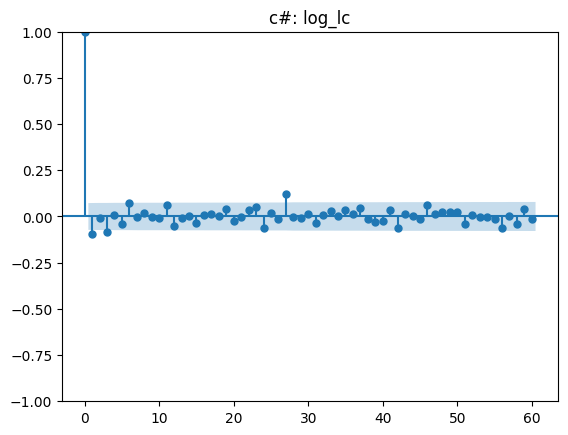

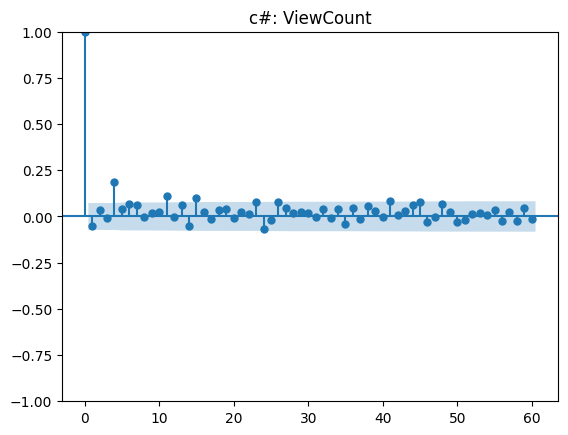

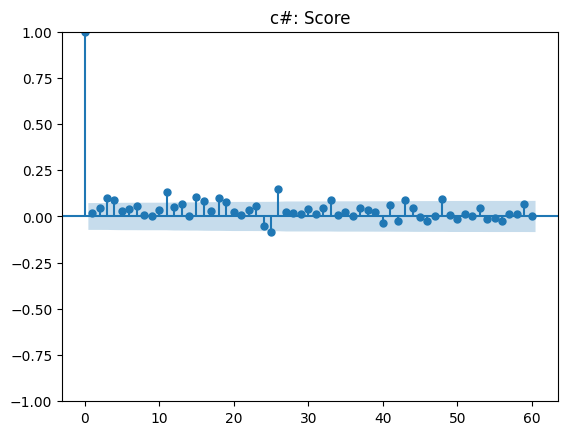

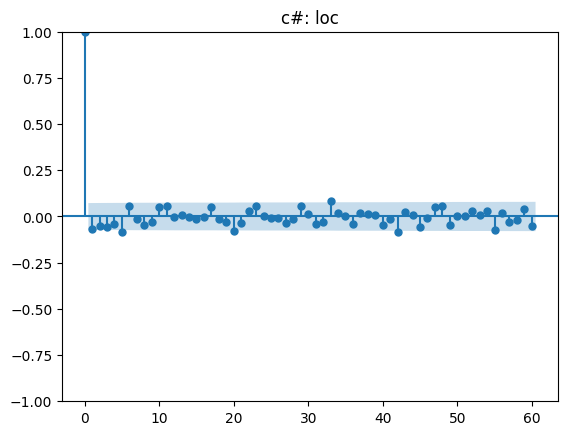

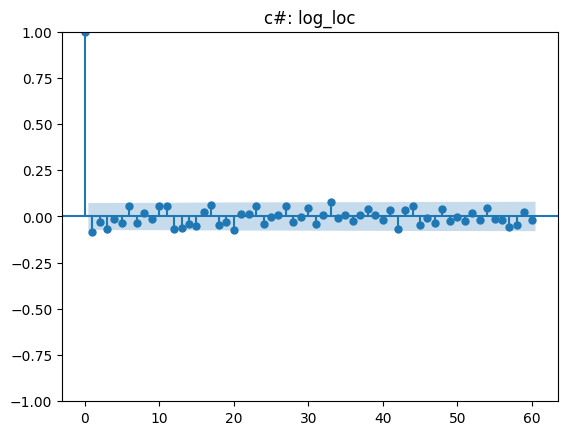

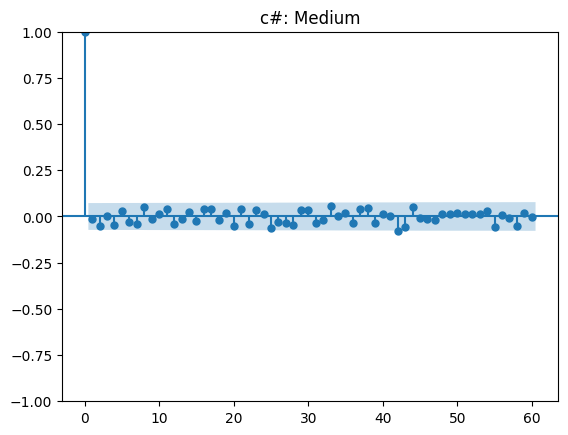

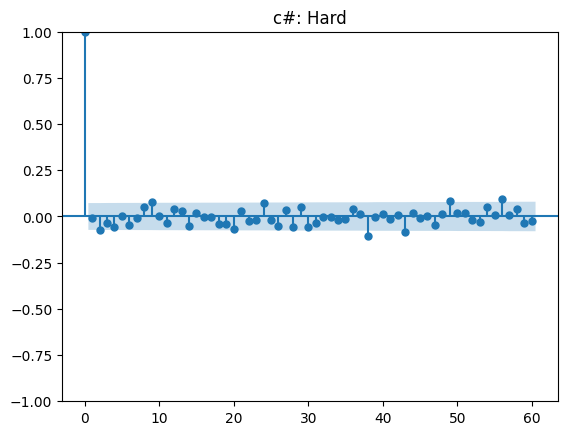

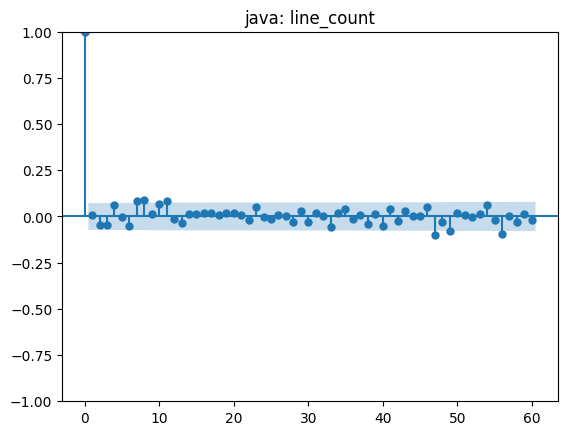

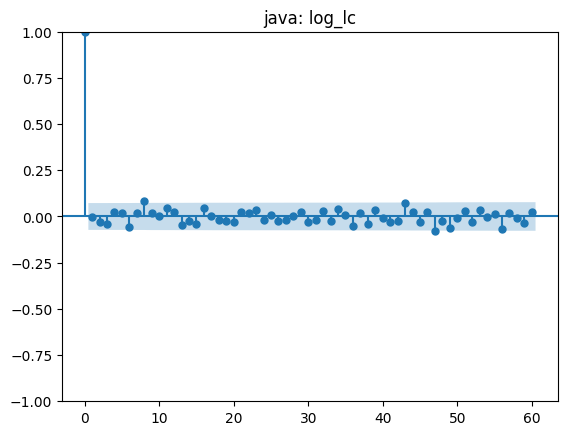

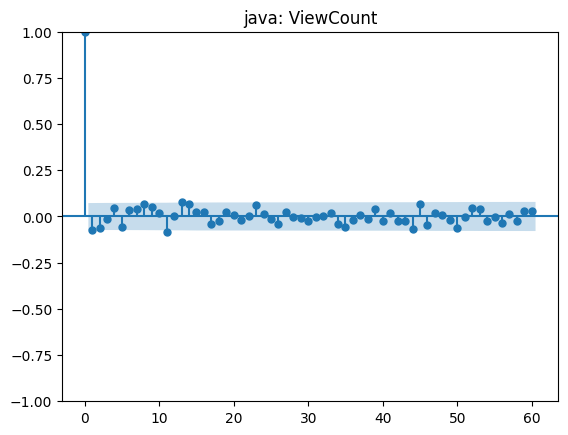

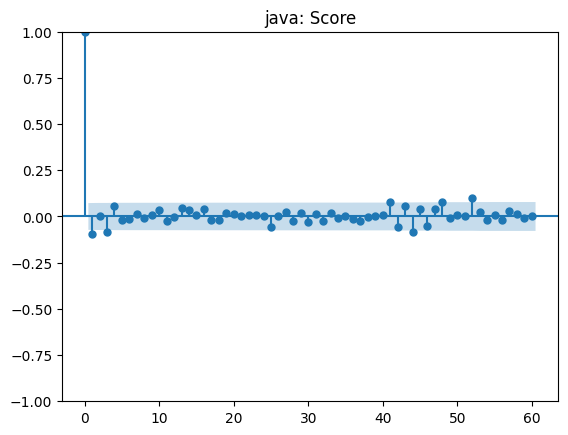

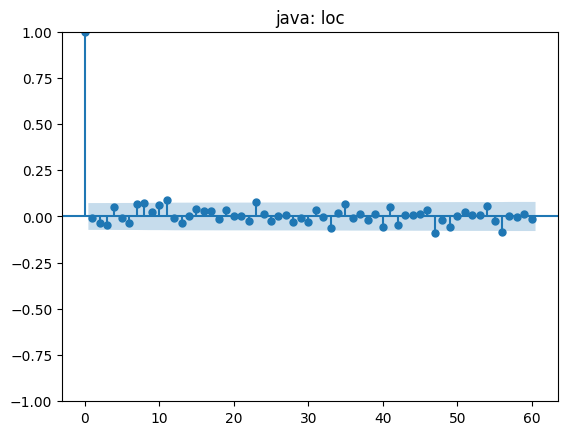

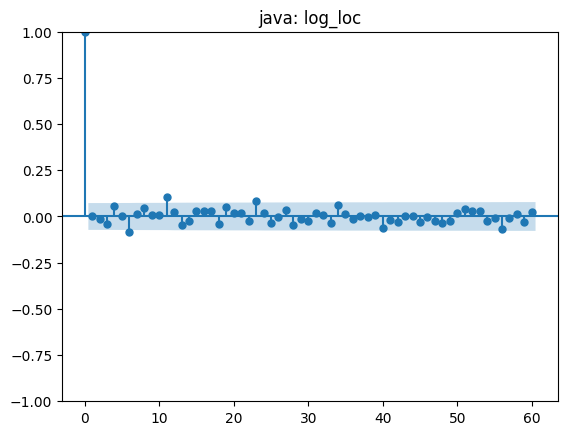

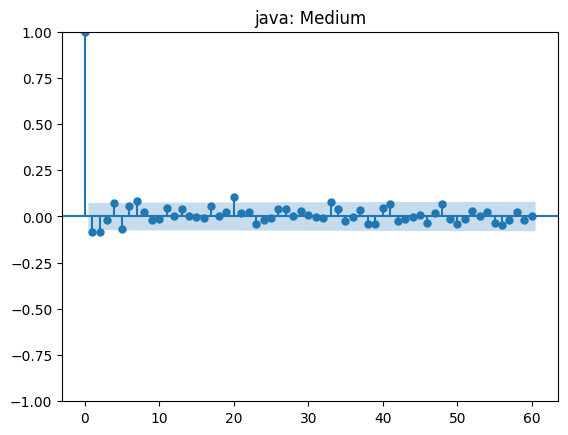

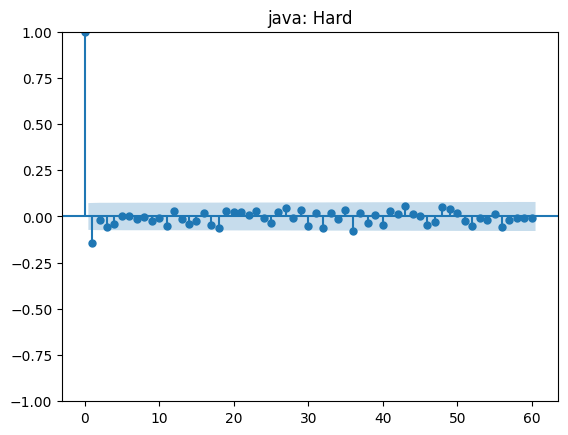

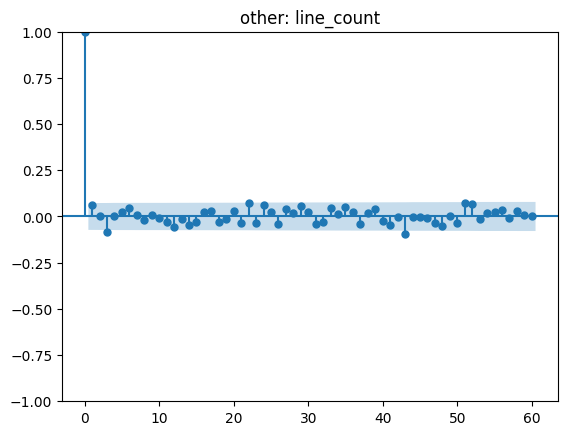

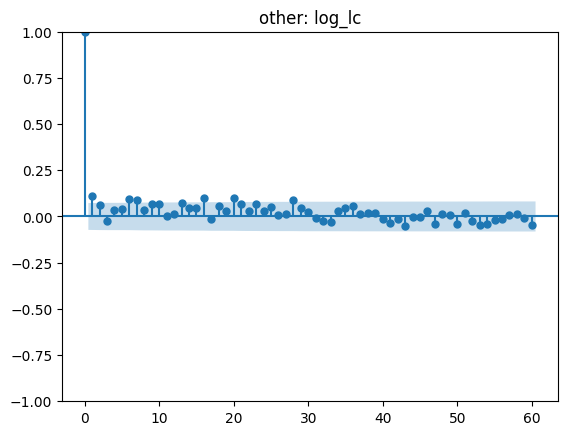

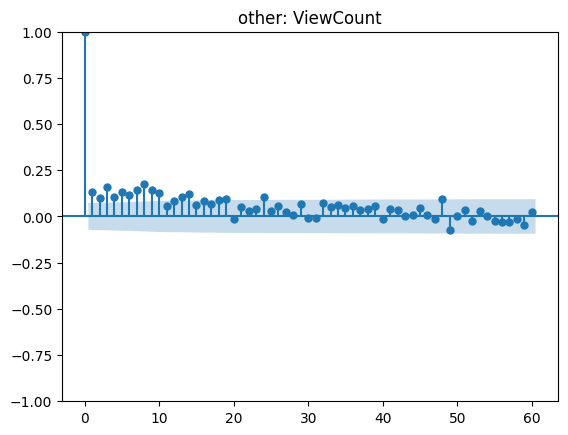

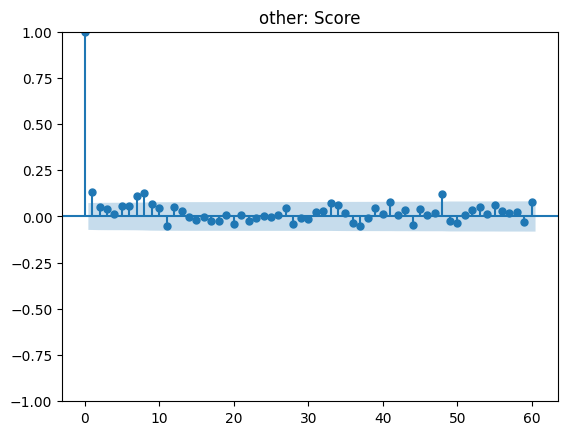

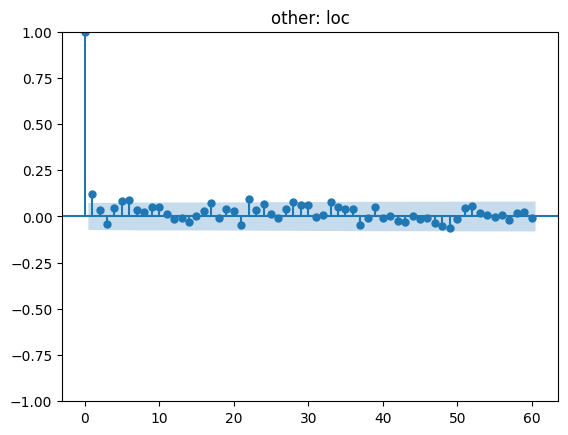

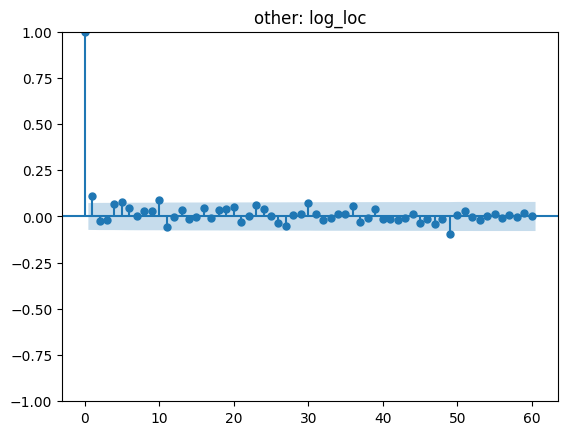

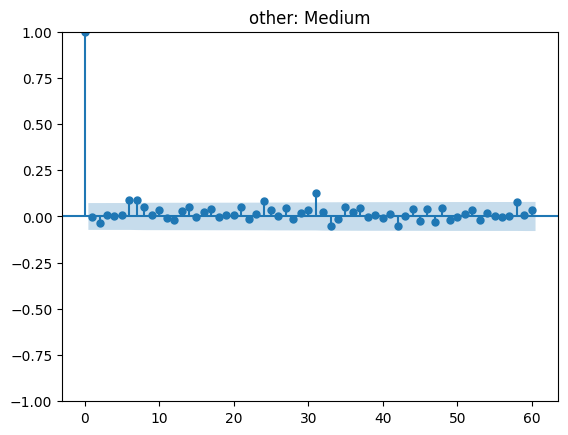

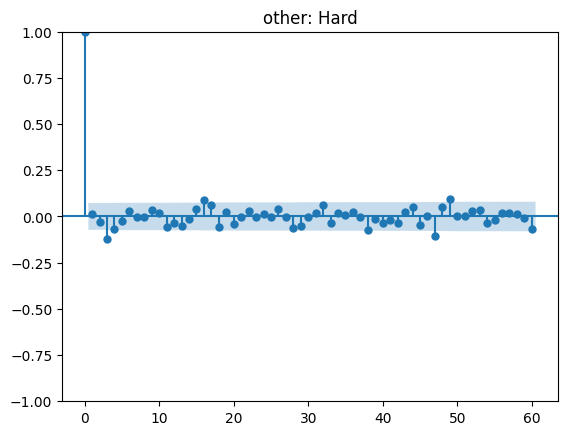

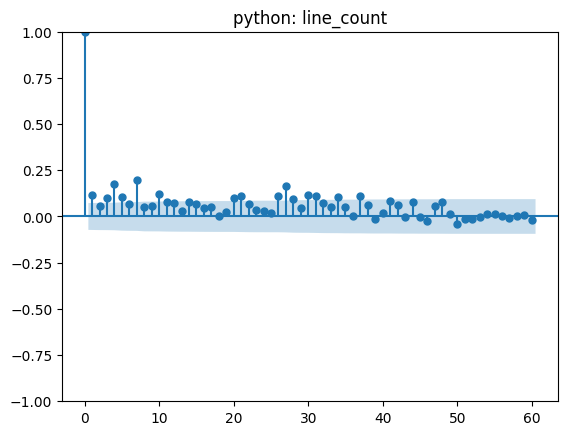

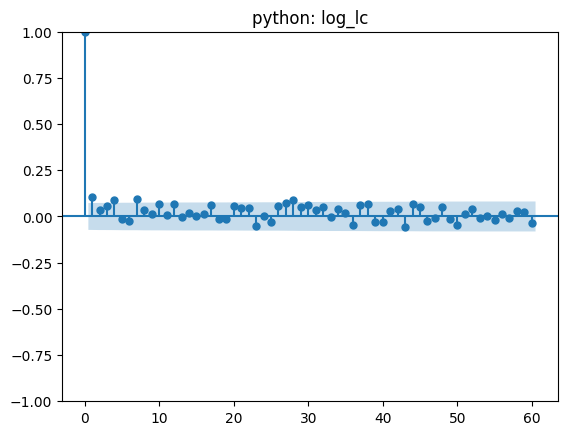

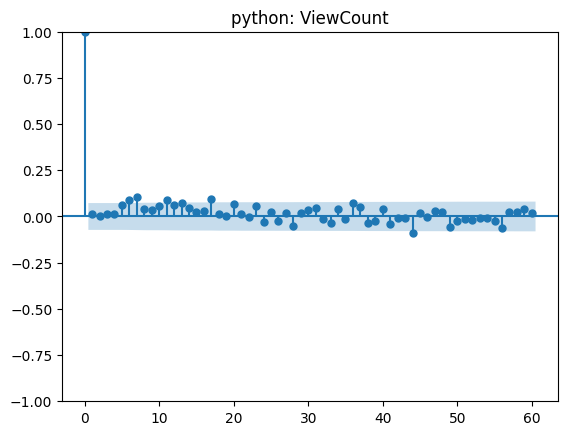

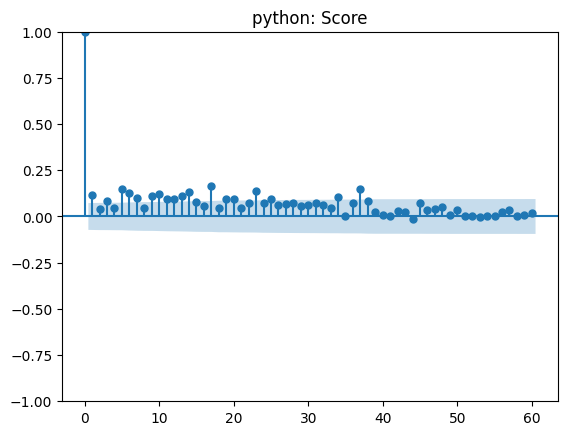

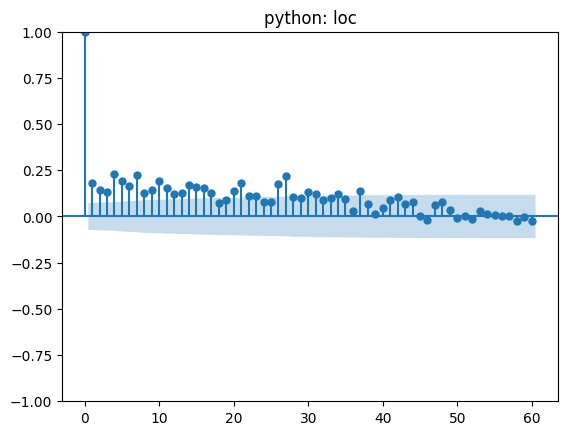

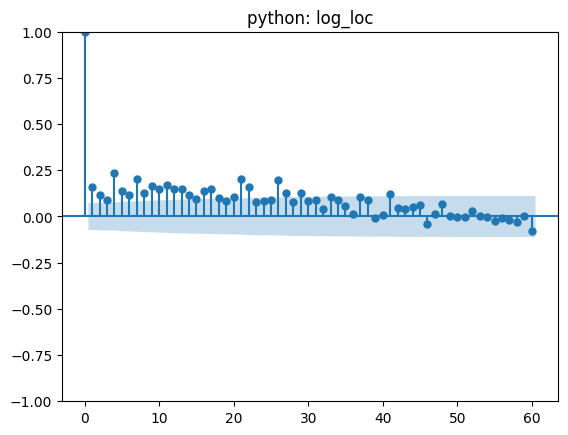

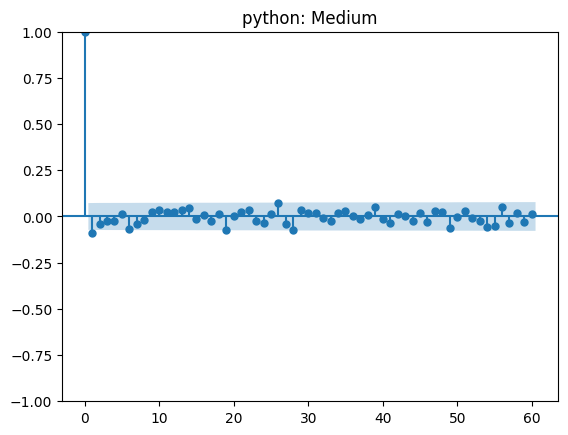

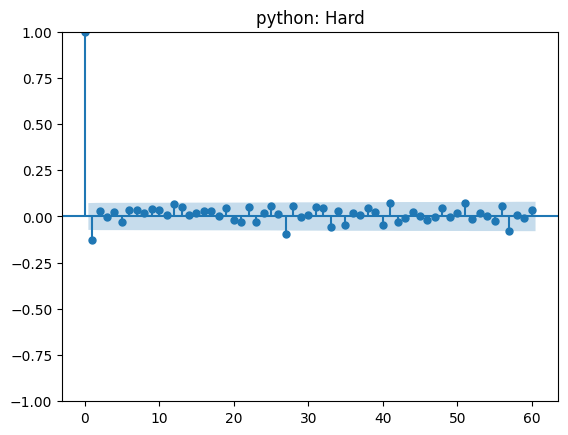

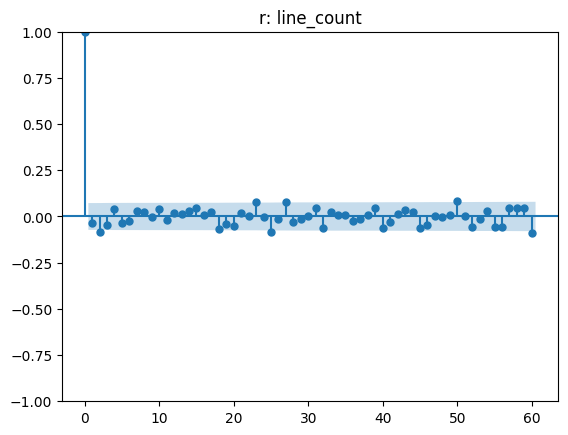

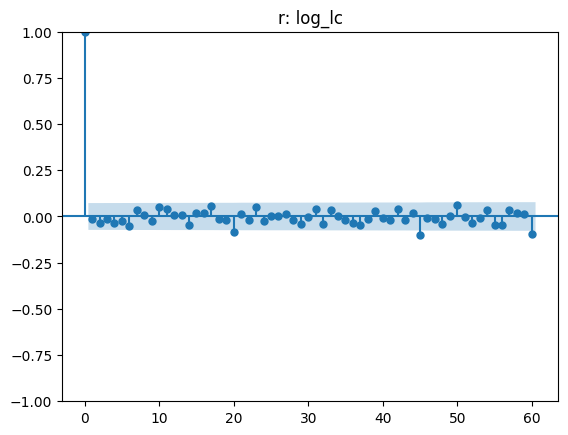

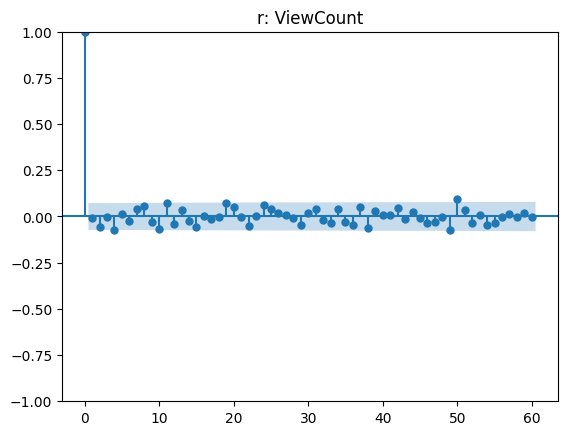

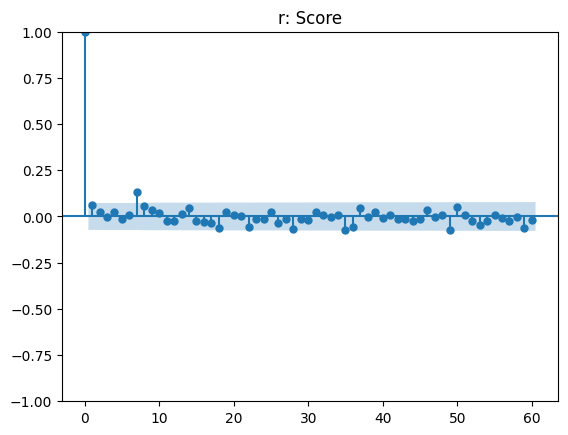

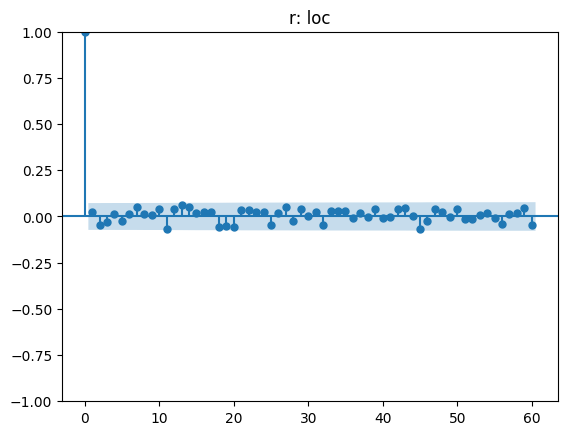

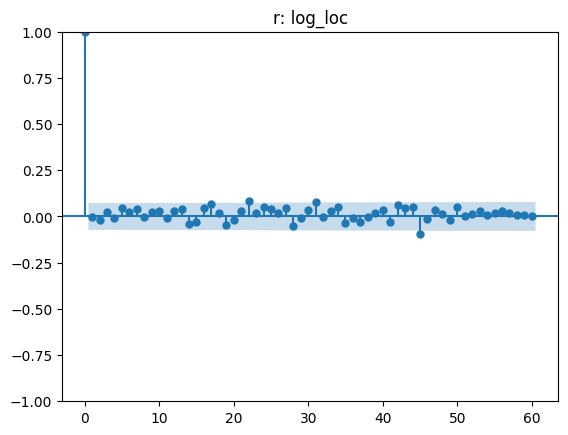

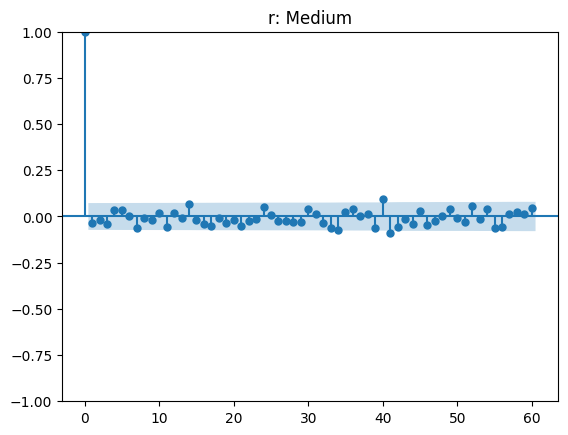

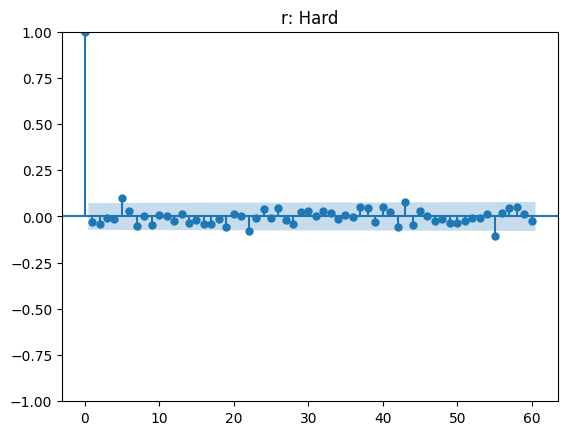

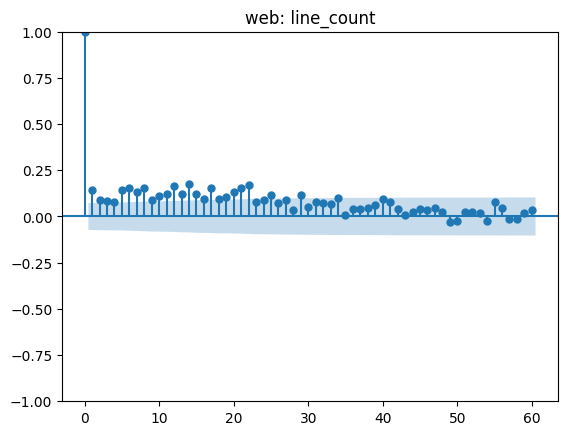

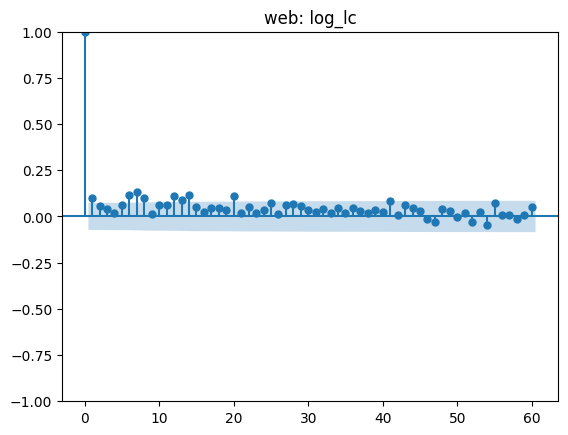

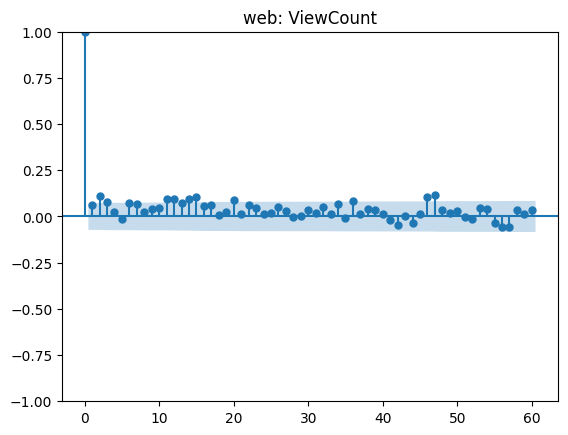

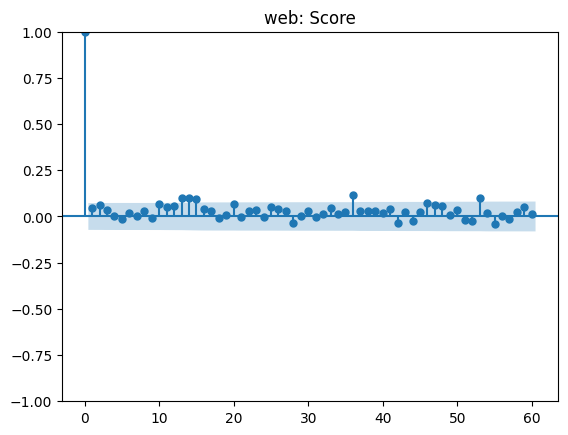

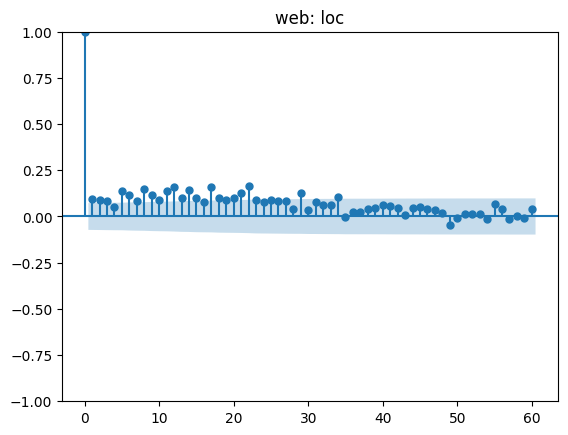

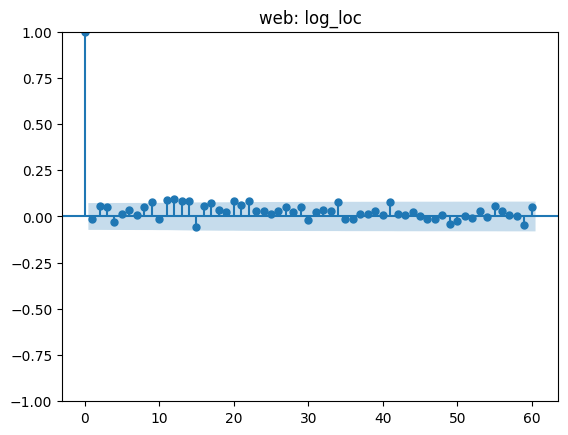

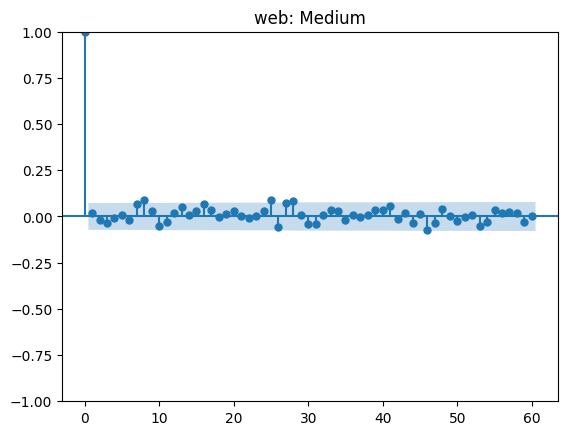

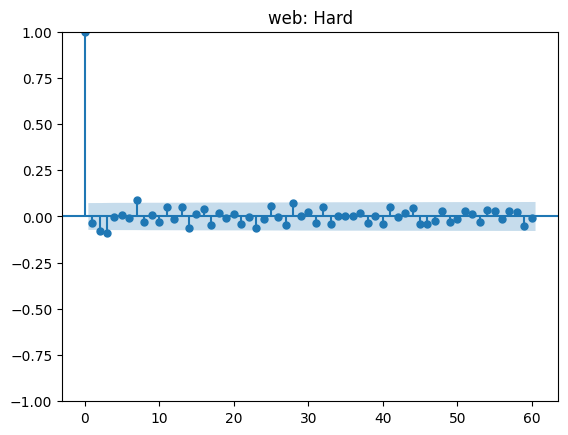

In [9]:
outcomes = ['line_count', 'log_lc', 'ViewCount', 'Score', 'loc', 'log_loc', 'Medium', 'Hard']
for tag in tags:
    for outcome in outcomes:
        acf(tag_dfs[tag], tag, outcome)

# Longest positive effect streak

In [10]:
def resample(dfs, results, outcomes, sample_function=so.block_bootstrap):
    L_hats = {}
    L_boots = {}
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print(f'Processing: {type} - {outcome}')
        
            L_hats[(type, outcome)] = so.effect_streak(results[(type, outcome)])

            res = so.resample_statistic(dfs[type], outcome, sample_function=sample_function, n_resamples=10)
            L_boot = [so.effect_streak(b) for b in res]
            L_boots[(type, outcome)] = pd.DataFrame(L_boot, columns=['sample_statistic'])
    
    return L_hats, L_boots

In [11]:
def resample_results(outcomes, L_hats, L_boots):
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print('-------------------------------------------')
            print(f'{type}: {outcome}')

            L_hat = L_hats[(type, outcome)]
            L_boot = L_boots[(type, outcome)]

            print('Observed longest run:', L_hat)
            print('Resample median:', np.median(L_boot))
            print('Resample 5% quantile:', np.quantile(L_boot, 0.05))

            lb_95 = np.quantile(L_boot, 0.05)
            lb_90 = np.quantile(L_boot, 0.10)
            print('95% lower bound on longest run:', int(lb_95))
            print('90% lower bound on longest run:', int(lb_90))

            p_ge_90  = (L_boot >= 90).mean()
            p_ge_100 = (L_boot >= 100).mean()
            print('P(run ≥ 90 days):', p_ge_90)
            print('P(run ≥ 100 days):', p_ge_100)

            p = (L_boot >= L_hat).mean()
            print('Probability for observed persistence:', p)

            print('95% interval:', np.quantile(L_boot, [0.025, 0.975]))

            plt.figure()
            sns.histplot(L_boot)
            plt.title(f'{type}: {outcome}')

## Question/answers

In [12]:
results = so.read_results('qa.csv')

In [13]:
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc']}

### Bootstrap distribution of the effect streak

Processing: questions - log_lc
Iteration: 0/10
Processing: answers - log_lc
Iteration: 0/10


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


-------------------------------------------
questions: log_lc
Observed longest run: 151
Resample median: 151.0
Resample 5% quantile: 97.45
95% lower bound on longest run: 97
90% lower bound on longest run: 133
P(run ≥ 90 days): sample_statistic    0.9
dtype: float64
P(run ≥ 100 days): sample_statistic    0.9
dtype: float64
Probability for observed persistence: sample_statistic    0.7
dtype: float64
95% interval: [ 79.225 151.   ]
-------------------------------------------
answers: log_lc
Observed longest run: 151
Resample median: 83.0
Resample 5% quantile: 50.8
95% lower bound on longest run: 50
90% lower bound on longest run: 52
P(run ≥ 90 days): sample_statistic    0.4
dtype: float64
P(run ≥ 100 days): sample_statistic    0.4
dtype: float64
Probability for observed persistence: sample_statistic    0.2
dtype: float64
95% interval: [ 49.9 151. ]


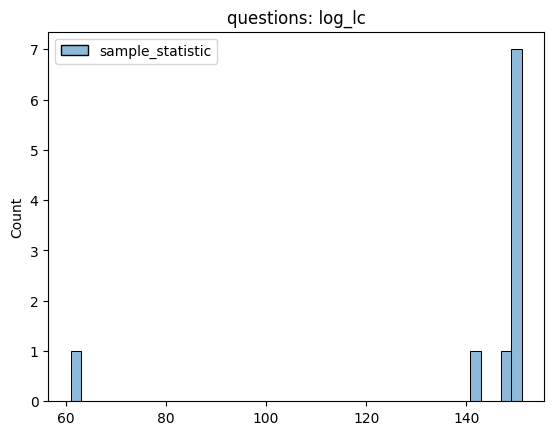

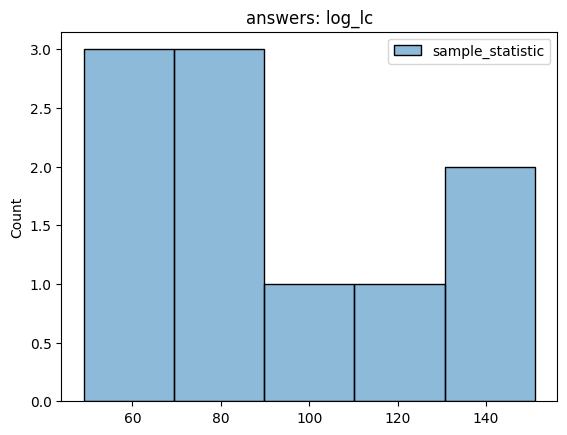

In [14]:
L_hats, L_boots = resample(dfs, results, outcomes)
so.store_results(L_boots, 'qa_boot.csv')
resample_results(outcomes, L_hats, L_boots)

### Permutation distribution of the effect streak

Processing: questions - log_lc
Iteration: 0/10
Processing: answers - log_lc
Iteration: 0/10
-------------------------------------------
questions: log_lc
Observed longest run: 151
Resample median: 0.0
Resample 5% quantile: 0.0
95% lower bound on longest run: 0
90% lower bound on longest run: 0
P(run ≥ 90 days): sample_statistic    0.0
dtype: float64
P(run ≥ 100 days): sample_statistic    0.0
dtype: float64
Probability for observed persistence: sample_statistic    0.0
dtype: float64
95% interval: [ 0.   39.95]
-------------------------------------------
answers: log_lc
Observed longest run: 151
Resample median: 0.0
Resample 5% quantile: 0.0
95% lower bound on longest run: 0
90% lower bound on longest run: 0
P(run ≥ 90 days): sample_statistic    0.0
dtype: float64
P(run ≥ 100 days): sample_statistic    0.0
dtype: float64
Probability for observed persistence: sample_statistic    0.0
dtype: float64
95% interval: [0. 0.]


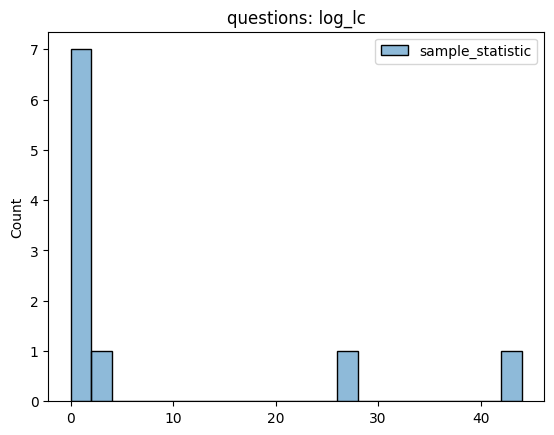

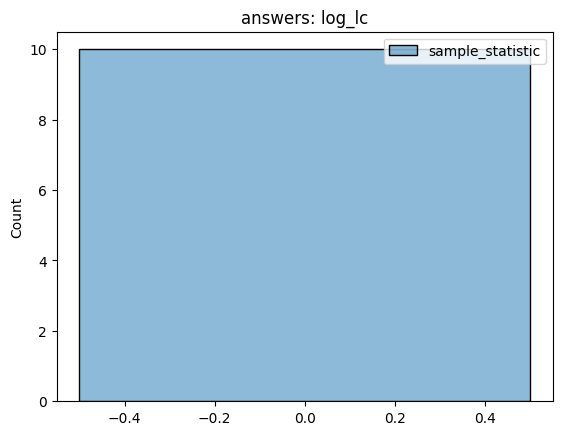

In [15]:
L_hats, L_boots = resample(dfs, results, outcomes, sample_function=so.permute_treatment)
so.store_results(L_boots, 'qa_perm.csv')
resample_results(outcomes, L_hats, L_boots)

## Tags

In [16]:
tag_results = so.read_results('tags.csv')

In [17]:
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'java': targets, 'python': targets, 'web': targets}

Processing: java - log_lc
Iteration: 0/10


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Processing: java - log_loc
Iteration: 0/10


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Processing: java - Medium
Iteration: 0/10
Processing: python - log_lc
Iteration: 0/10


...

Processing: python - log_loc
Iteration: 0/10
Processing: python - Medium
Iteration: 0/10


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Processing: web - log_lc
Iteration: 0/10


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Processing: web - log_loc
Iteration: 0/10
Processing: web - Medium
Iteration: 0/10
-------------------------------------------
java: log_lc
Observed longest run: 98
Resample median: 49.5
Resample 5% quantile: 36.15
95% lower bound on longest run: 36
90% lower bound on longest run: 39
P(run ≥ 90 days): sample_statistic    0.1
dtype: float64
P(run ≥ 100 days): sample_statistic    0.1
dtype: float64
Probability for observed persistence: sample_statistic    0.1
dtype: float64
95% interval: [ 34.575 105.425]
-------------------------------------------
java: log_loc
Observed longest run: 62
Resample median: 27.5
Resample 5% quantile: 13.15
95% lower bound on longest run: 13
90% lower bound on longest run: 16
P(run ≥ 90 days): sample_statistic    0.0
dtype: float64
P(run ≥ 100 days): sample_statistic    0.0
dtype: float64
Probability for observed persistence: sample_statistic    0.0
dtype: float64
95% interval: [11.575 44.875]
-------------------------------------------
java: Medium
Observed 

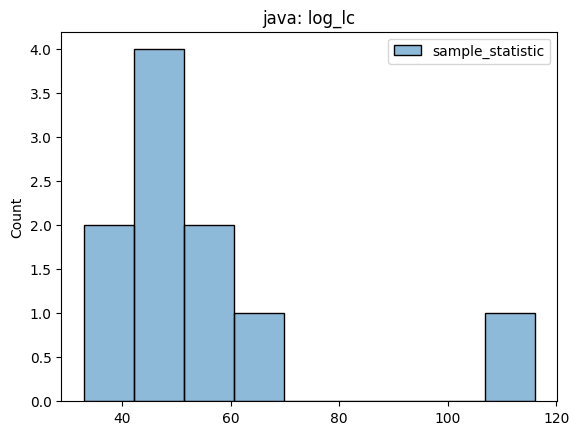

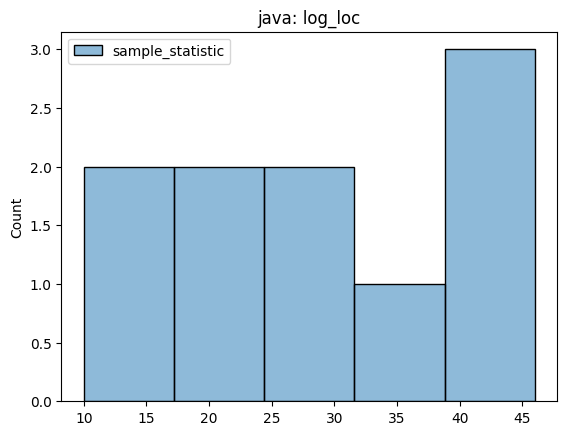

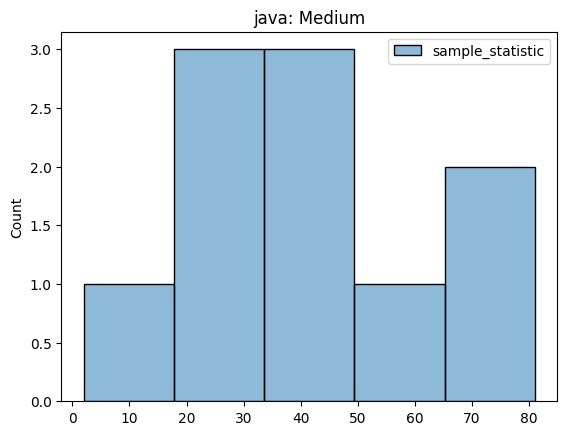

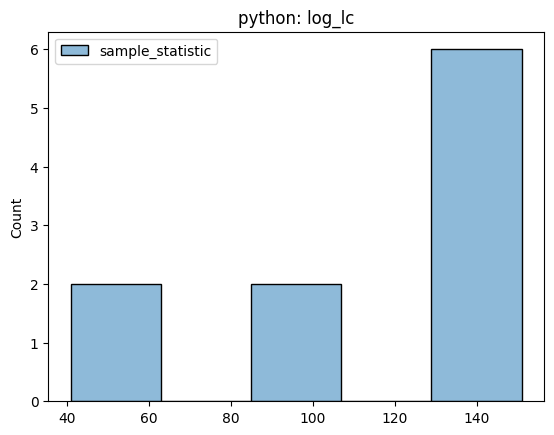

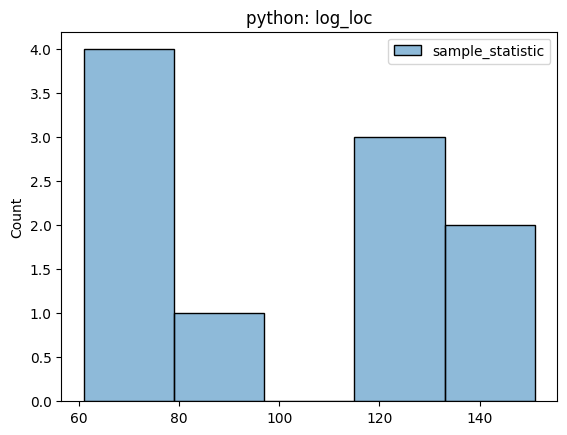

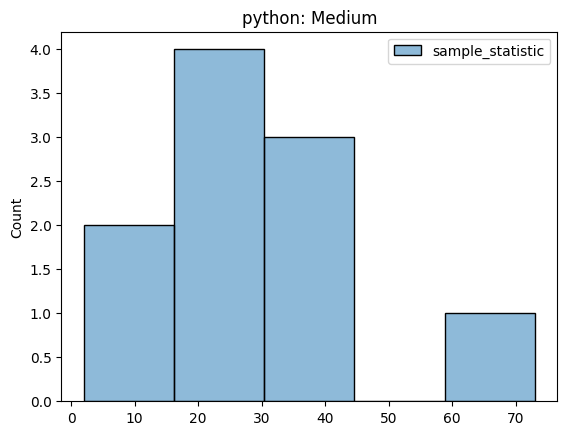

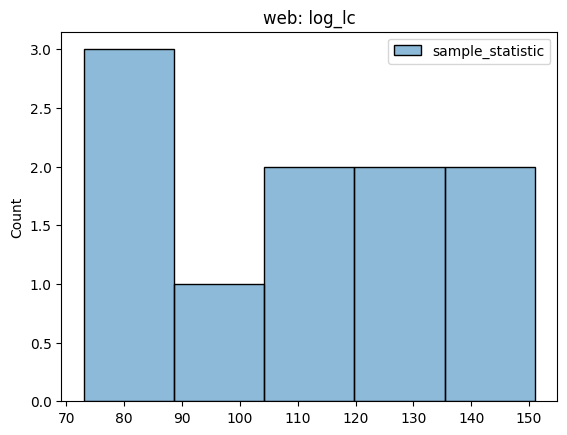

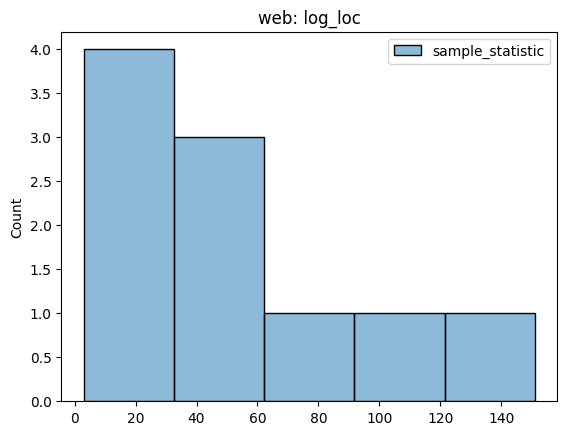

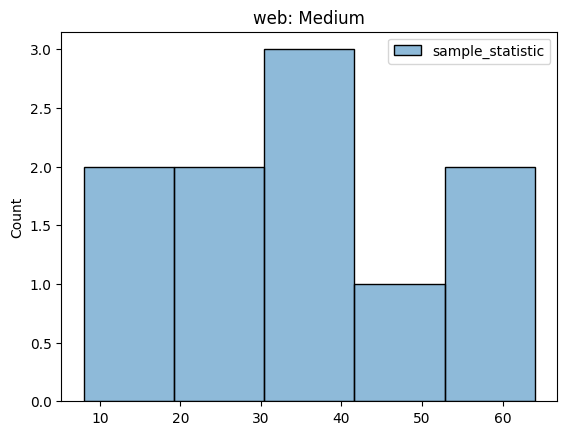

In [18]:
L_hats, L_boots = resample(tag_dfs, tag_results, outcomes)
so.store_results(L_boots, 'tags_boot.csv')
resample_results(outcomes, L_hats, L_boots)

Processing: java - log_lc
Iteration: 0/10
Processing: java - log_loc
Iteration: 0/10
Processing: java - Medium
Iteration: 0/10
Processing: python - log_lc
Iteration: 0/10
Processing: python - log_loc
Iteration: 0/10
Processing: python - Medium
Iteration: 0/10
Processing: web - log_lc
Iteration: 0/10
Processing: web - log_loc
Iteration: 0/10
Processing: web - Medium
Iteration: 0/10
-------------------------------------------
java: log_lc
Observed longest run: 98
Resample median: 0.0
Resample 5% quantile: 0.0
95% lower bound on longest run: 0
90% lower bound on longest run: 0
P(run ≥ 90 days): sample_statistic    0.1
dtype: float64
P(run ≥ 100 days): sample_statistic    0.1
dtype: float64
Probability for observed persistence: sample_statistic    0.1
dtype: float64
95% interval: [  0.    119.725]
-------------------------------------------
java: log_loc
Observed longest run: 62
Resample median: 0.0
Resample 5% quantile: 0.0
95% lower bound on longest run: 0
90% lower bound on longest run:

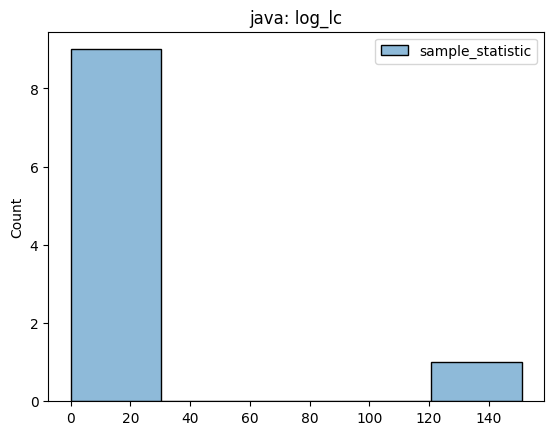

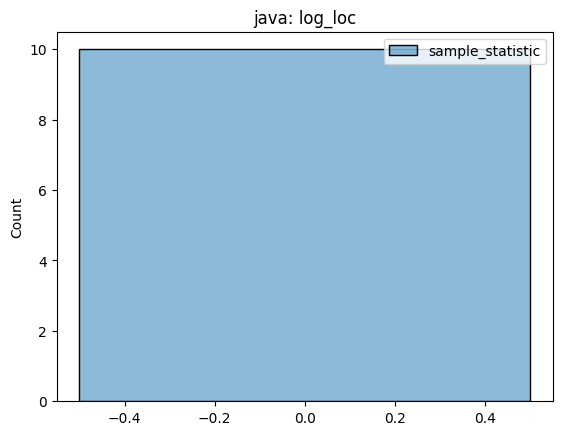

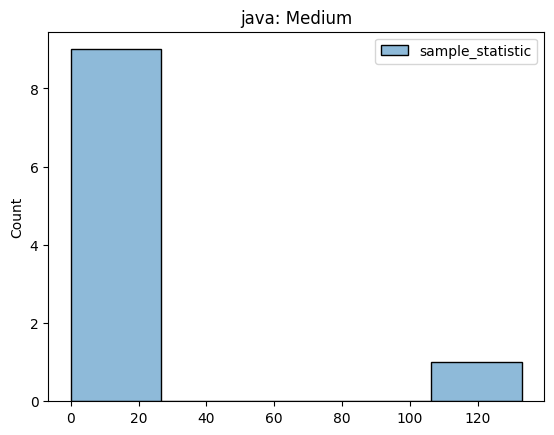

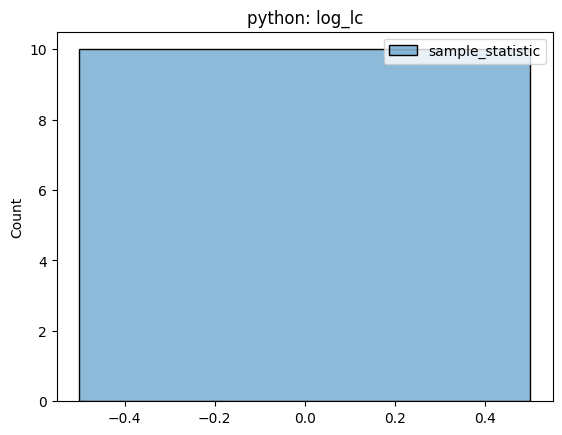

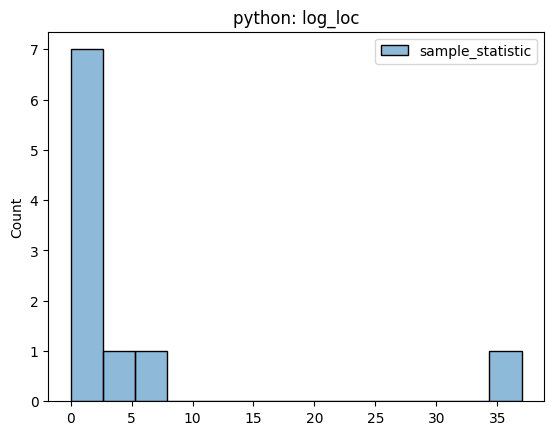

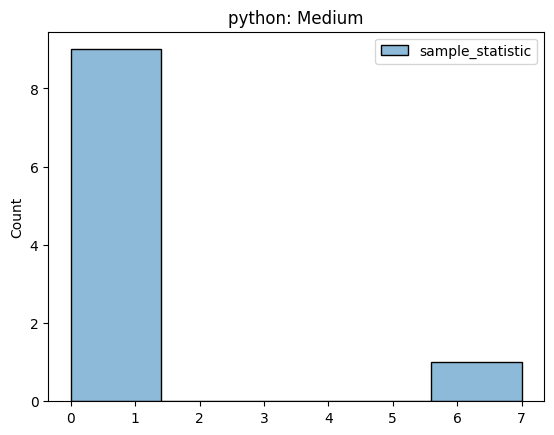

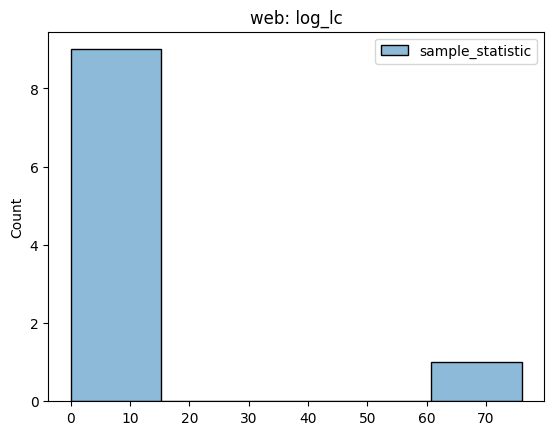

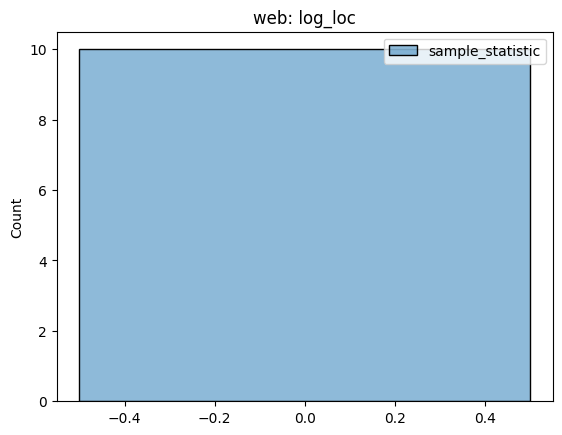

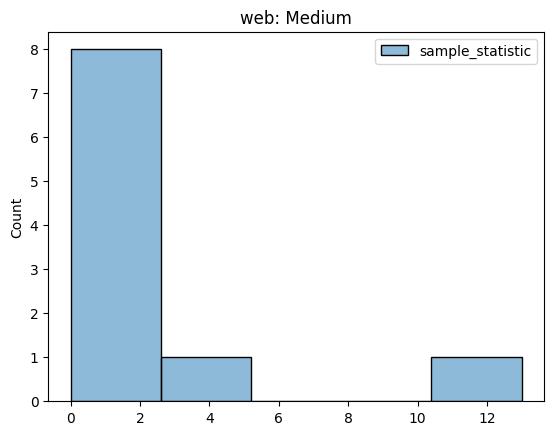

In [19]:
L_hats, L_boots = resample(tag_dfs, tag_results, outcomes, sample_function=so.permute_treatment)
so.store_results(L_boots, 'tags_perm.csv')
resample_results(outcomes, L_hats, L_boots)

In [20]:
# #placebo_t = '2023-02-28'
# #placebo_c = '2022-02-28'
# #shifted_t = (pd.to_datetime(placebo_t) - pd.DateOffset(months=6)).strftime("%Y-%m-%d")
# #shifted_c = (pd.to_datetime(placebo_c) - pd.DateOffset(months=6)).strftime("%Y-%m-%d")

# #shifted_str = shifted
# placebo_t = '2022-08-31'
# placebo_c = '2021-08-31'
# shifted_t = (pd.to_datetime(placebo_t) + pd.DateOffset(days=151)).strftime("%Y-%m-%d")


# #start_dates, masks = so.rolling_window_masks(q_daily, data_column='date', normalized=True, window_days=30, pre_end=placebo_t, pre_end_c=placebo_c, pre_start=shifted_t, pre_start_c=shifted_c)
# start_dates, masks = so.rolling_window_masks(q_daily, data_column='date', normalized=True, window_days=30, pre_end=placebo_t, pre_end_c=placebo_c, end=shifted_t)

# daily = q_daily.copy()
# daily['P'] = (((daily['date'] >= pd.to_datetime(placebo_t)) & (daily['date'] <= pd.to_datetime('2023-05-29'))) | 
#               ((daily['date'] >= pd.to_datetime(placebo_c)) & (daily['date'] <= pd.to_datetime('2022-05-30')))).astype(int)

# X, y = so.did_design_matrix(f'line_count_bar', daily)
# res = so.did_wls(daily, X, y, masks, start_dates, 'line_count')